## **Praktikum Mandiri 06**

In [2]:
# Menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Untuk Visualisasi 3D
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

In [4]:
print("1. LOAD DATASET")
df = pd.read_csv("/content/gdrive/MyDrive/Semester_7/praktikum_ml/praktikum06/data/spam.csv", sep=',', encoding='latin-1')

# Bersihkan dan ubah nama kolom
df.columns = ['Category', 'Message']
df = df.dropna()

print(f"Bentuk data (baris, kolom): {df.shape}")
print("5 Baris Pertama:")
print(df.head())

1. LOAD DATASET
Bentuk data (baris, kolom): (5572, 2)
5 Baris Pertama:
  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


In [5]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [6]:
print("2. PREPROCESSING TEKS DAN EKSTRAKSI FITUR")

# 2a. Label Encoding (Mengubah 'ham'/'spam' menjadi 0/1)
le = LabelEncoder()
df['Category_Encoded'] = le.fit_transform(df['Category'])

# 2b. Text Preprocessing (Cleaning, Stopwords, Stemming)
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Membersihkan teks (hanya menyisakan huruf) dan lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower()
    # Tokenisasi dan Stemming
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['Processed_Message'] = df['Message'].apply(preprocess_text)

# 2c. Feature Extraction menggunakan TF-IDF
X = df['Processed_Message']
y = df['Category_Encoded']

# Bagi data untuk Vectorizer
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inisialisasi TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Terapkan TF-IDF
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print(f"Jumlah Fitur setelah TF-IDF: {X_train_vec.shape[1]}")

2. PREPROCESSING TEKS DAN EKSTRAKSI FITUR
Jumlah Fitur setelah TF-IDF: 5000


In [9]:
print("3. SPLIT DAN BANGUN MODEL SVM")
# Split sudah dilakukan pada langkah 2c.

# Inisialisasi model Support Vector Classifier (SVC)
# Menggunakan kernel 'linear' yang efektif untuk data teks
svm_model = SVC(kernel='linear', random_state=42)

# Latih model
svm_model.fit(X_train_vec, y_train)
print("Model SVM (Kernel Linear) berhasil dilatih.")

3. SPLIT DAN BANGUN MODEL SVM
Model SVM (Kernel Linear) berhasil dilatih.


In [10]:
print("4. EVALUASI AKURASI DAN REPORT KLASIFIKASI")
y_pred = svm_model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['ham (0)', 'spam (1)'])

print(f"Akurasi Model: {accuracy:.4f}")
print("\nLaporan Klasifikasi:")
print(report)

4. EVALUASI AKURASI DAN REPORT KLASIFIKASI
Akurasi Model: 0.9865

Laporan Klasifikasi:
              precision    recall  f1-score   support

     ham (0)       0.99      1.00      0.99       966
    spam (1)       0.99      0.91      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



In [11]:
print("5. CONFUSION MATRIX")
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print(
    f"\nPenjelasan CM:\n"
    f"True Negative (Ham diprediksi Ham): {cm[0, 0]}\n"
    f"False Positive (Ham diprediksi Spam): {cm[0, 1]}\n"
    f"False Negative (Spam diprediksi Ham): {cm[1, 0]}\n"
    f"True Positive (Spam diprediksi Spam): {cm[1, 1]}"
)

5. CONFUSION MATRIX
Confusion Matrix:
[[965   1]
 [ 14 135]]

Penjelasan CM:
True Negative (Ham diprediksi Ham): 965
False Positive (Ham diprediksi Spam): 1
False Negative (Spam diprediksi Ham): 14
True Positive (Spam diprediksi Spam): 135


6. VISUALISASI HASIL MODEL SVM (2D PCA)


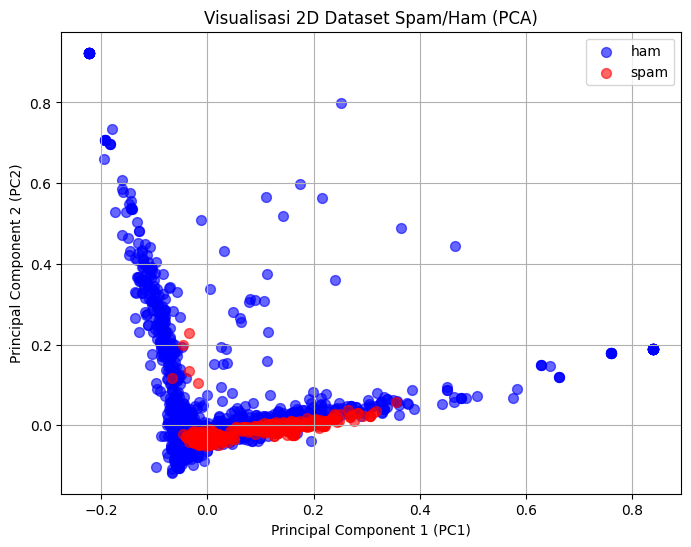

Visualisasi 2D berhasil ditampilkan. 


In [12]:
print("6. VISUALISASI HASIL MODEL SVM (2D PCA)")

# Data untuk visualisasi (semua data)
X_full_vec = tfidf.transform(df['Processed_Message'])
y_full_labels = df['Category']

# Reduksi dimensi dari N fitur ke 2 dimensi
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_full_vec.toarray())

pca_df_2d = pd.DataFrame(data = X_pca_2d, columns = ['PC1', 'PC2'])
pca_df_2d['Category'] = y_full_labels

plt.figure(figsize=(8, 6))
targets = ['ham', 'spam']
colors = ['blue', 'red']

for target, color in zip(targets, colors):
    indices_to_keep = pca_df_2d['Category'] == target
    plt.scatter(pca_df_2d.loc[indices_to_keep, 'PC1'],
                pca_df_2d.loc[indices_to_keep, 'PC2'],
                c = color,
                s = 50,
                alpha = 0.6,
                label = target)

plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('Visualisasi 2D Dataset Spam/Ham (PCA)')
plt.legend()
plt.grid(True)
plt.show()

print("Visualisasi 2D berhasil ditampilkan. ")

7. 3D VISUALISASI HASIL MODEL SVM (3D PCA)


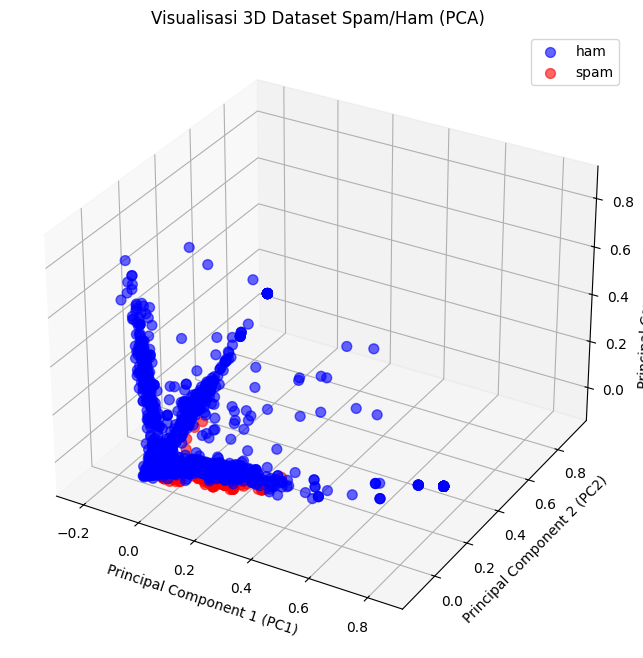

Visualisasi 3D berhasil ditampilkan. 


In [13]:
print("7. 3D VISUALISASI HASIL MODEL SVM (3D PCA)")

# Reduksi dimensi dari N fitur ke 3 dimensi
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_full_vec.toarray())

pca_df_3d = pd.DataFrame(data = X_pca_3d, columns = ['PC1', 'PC2', 'PC3'])
pca_df_3d['Category'] = y_full_labels

# Plot 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for target, color in zip(targets, colors):
    indices_to_keep = pca_df_3d['Category'] == target
    ax.scatter(pca_df_3d.loc[indices_to_keep, 'PC1'],
               pca_df_3d.loc[indices_to_keep, 'PC2'],
               pca_df_3d.loc[indices_to_keep, 'PC3'],
               c = color,
               s = 50,
               alpha = 0.6,
               label = target)

ax.set_xlabel('Principal Component 1 (PC1)')
ax.set_ylabel('Principal Component 2 (PC2)')
ax.set_zlabel('Principal Component 3 (PC3)')
ax.set_title('Visualisasi 3D Dataset Spam/Ham (PCA)')
ax.legend()
plt.show()

print("Visualisasi 3D berhasil ditampilkan. ")